# MOD510: Project 3

**Deadline: 04. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : ...

**Intro here**

## Part 1

In [1]:
import numpy as np
import math
import numba_rk4

def func():
    '''
    dr/dt = f(r,t) , r and f are vectors
    r = (x, y, ...)
    f(r,t) = (fx(r,t), fy(r,t))
    '''
    pass

class ode_solver:
    '''
    Class docstring
    '''
    def __init__(self, f, t0, tf, h, r0, method = 'rk4', max_tol = 1e-5, adaptive = True):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        self.n = math.ceil((tf - t0) / h)
        self.t_points = np.zeros(self.n, float)
        self.r0 = np.array(r0, float)
        self.method = method
        self.choosen_method = {'eulers': self.__eulers,
                               'rk2': self.__rk2,
                               'rk4': self.__rk4,
                               'fast_rk4': 'numba_rk4'
                               }[method]
        self.r_points = np.zeros((self.n, len(self.r0)), float)
        self.adaptive = adaptive
        self.step_exponent = {"euler":1/2, "impeuler":1/3, "rk2":1/3, "rk4":1/5, 'fast_rk4':1/5}[method]
        self.max_tol = max_tol

    def __eulers(self, t, r, h):
        '''
        Eulers method
        '''
        return h * self.f(r, t)

    def __rk2(self, t, r, h):
        '''
        Runge-Kutta second order (RK2)
        '''
        k1 = h * self.f(r, t)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h)
        return k2

    def __rk4(self, t, r, h):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        k1 = h * self.f(r, t)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h)
        k3 = h * self.f(r + 0.5 * k2, t + 0.5 * h)
        k4 = h * self.f(r + k3, t + h)
        return (k1 + 2 * (k2 + k3) + k4) / 6

    #def __fast_rk4(self, t, h):
    #    return numba_rk4.solve(self.f, h, self.r0, self.t_points)

    def solve(self):
        '''
        Doc string for solve function
        '''

        self.r_points[0] = self.r0
        self.t_points[0] = self.t0

        if self.choosen_method == 'numba_rk4':
            self.t_points, self.r_points = numba_rk4.solve(self.f, self.h, self.t0, self.tf, self.r0, self.t_points, self.r_points, self.adaptive, self.max_tol)
        else:
            h = self.h
            t = self.t0
            i = 0

            while t < self.tf:
                r_i = self.r_points[i]

                if self.adaptive:
                    r1 = r_i + self.choosen_method(t, r_i, h)
                    r_half = r_i + self.choosen_method(t, r_i, h/2)
                    r2 = r_half + self.choosen_method(t + h / 2, r_half, h/2)
                    Err = np.max(np.abs(r2 - r1))
                    Err = max(Err, 1e-14)
                    h = h*(self.max_tol / Err)**self.step_exponent
                h = min(h, self.tf - t)  # Do not step beyond tf/avoid overshooting
                self.r = r_i + self.choosen_method(t, r_i, h)
                self.r_points[i + 1]= self.r.copy()
                t += h
                self.t_points[i + 1]= t
                i += 1
            self.t_points = self.t_points[:i+1]
            self.r_points = self.r_points[:i+1]

        return self.t_points, self.r_points




## Part 2

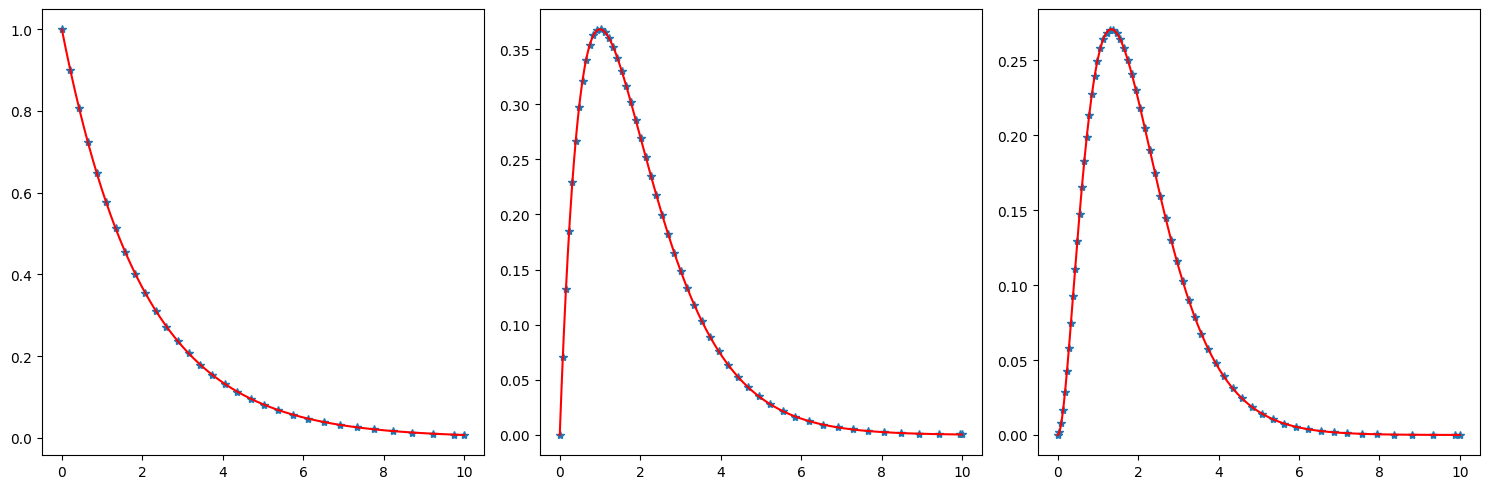

In [5]:
import matplotlib.pyplot as plt
import math
from numba import njit

@njit
def cd_0(r, t, n = 1, tau = 2):
    """ 1 tank"""
    Cin = 0 # input concentration = 0
    return (n/tau)*(Cin - r[0])

@njit
def cd_1(r, t, n = 2, tau = 2):
    """ 2 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    return rp

@njit
def cd_2(r, t, n = 3, tau = 2):
    """ 3 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    rp[2] = (n/tau)*(r[1]- r[2])
    return rp

@njit
def c_0(t, tau = 2):
    return np.exp(-t / tau)

@njit
def c_1(t, tau = 2):
    return (2 * t / tau) * np.exp(-2 * t / tau)

@njit
def c_2(t, tau = 2):
    return 9* t**2 / (2 * tau**2) * np.exp(-3 * t / tau)

cake = ode_solver(cd_0, 0, 10, 1e-2, [1], 'fast_rk4', 1e-7)
t, sol = cake.solve()
cake1 = ode_solver(cd_1, 0, 10, 1e-2, [1, 0], 'fast_rk4', 1e-7)
t1, sol1 = cake1.solve()
cake2 = ode_solver(cd_2, 0, 10, 1e-2, [1, 0, 0], 'fast_rk4', 1e-7)
t2, sol2 = cake2.solve()

ta = np.linspace(0, 10, 1000)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(t, sol, '*',label = "rk4")
plt.plot(ta, c_0(ta), '-',color = 'red', label = "analytical")

plt.subplot(1, 3, 2)
plt.plot(t1, sol1[: ,1], '*',label = "rk4")
plt.plot(ta, c_1(ta), '-', color = 'red', label = "analytical")

plt.subplot(1, 3, 3)
plt.plot(t2, sol2[:, 2], '*',label = "rk4")
plt.plot(ta, c_2(ta), '-', color = 'red', label = "analytical")

plt.tight_layout()
plt.show()

In [3]:
import timeit

number = 100
cake = ode_solver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'fast_rk4', 1e-7)
cake2 = ode_solver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'rk4', 1e-7)

t = timeit.timeit(lambda: cake.solve(), number = number) / number
t2 = timeit.timeit(lambda: cake2.solve(), number = number) / number

print(f"With numba: {t}s")
print(f"Without numba: {t2}s")
print(f"With numba is {t2/t} times faster")

With numba: 0.00021207499999945868s
Without numba: 0.07231835900000078s
With numba is 341.00369680624954 times faster
